In [1]:
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------
# Load dataset
# -----------------------
def loadDataSet():
    fnSave = 'project2.dat'
    print(f'Loading data from {fnSave}')
    with open(fnSave, 'rb') as f:
        res = pickle.load(f)
    X_train = res['X_train']
    L_train = res['L_train'].astype(int)
    X_test = res['X_test']
    L_test = res['L_test'].astype(int)
    numCat = res['numCat']
    return X_train, L_train, X_test, L_test, numCat

# -----------------------
# Activation functions and loss function
# -----------------------
def relu(z):
    return np.maximum(0, z)

# gradient of ReLU = step function
def relu_grad(z):
    return (z > 0).astype(float)

def softmax(z):
# divide by max for numerical stability and avoid numerical overflow   
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot(labels, K):
# one-hot encoding of labels into a 2D binary matrix with K columns (number of classes) and rows corresponding to data points.
    Y = np.zeros((len(labels), K))
    Y[np.arange(len(labels)), labels] = 1.0
    return Y

def cross_entropy(Y, Q):
# Q is the 2D matrix of predicted probability distribution, Y is the one-hot encoded true labels    
    eps = 1e-12
    return -np.mean(np.sum(Y * np.log(Q + eps), axis=1))


In [2]:
# -----------------------
# Shallow MLP
# -----------------------
class ShallowMLP:
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=10, seed=None):
        rng = np.random.default_rng(seed)

        # HE init with random initial weights from normal distribution and 0 biases
        self.W1 = rng.normal(0, np.sqrt(2 / input_dim), size=(hidden_dim, input_dim))
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = rng.normal(0, np.sqrt(2 / hidden_dim), size=(output_dim, hidden_dim))
        self.b2 = np.zeros((1, output_dim))

    def forward(self, X):
        # Z1 is the pre-activation of the hidden layer, A1 is the post-activation (after ReLU) 
        # Z2 is the pre-activation of the output layer, and Q is the final output probabilities after softmax.
        self.Z1 = X @ self.W1.T + self.b1           # (B, N)
        self.A1 = relu(self.Z1)                     # (B, N)
        self.Z2 = self.A1 @ self.W2.T + self.b2     # (B, K)
        self.Q = softmax(self.Z2)                   # (B, K)
        return self.Q

    def backward(self, X, Y):
        # B is the batch size
        B = X.shape[0]      

        # output error
        dZ2 = (self.Q - Y) / B                      # (B, K)

        # gradients for W2, b2
        dW2 = dZ2.T @ self.A1                       # (K, N)
        db2 = np.sum(dZ2, axis=0, keepdims=True)    # (1, K)

        # hidden error
        dZ1 = (dZ2 @ self.W2) * relu_grad(self.Z1)  # (B, N)

        # gradients for W1, b1
        dW1 = dZ1.T @ X                             # (N, 2)
        db1 = np.sum(dZ1, axis=0, keepdims=True)    # (1, N)

        return dW1, db1, dW2, db2

    def step(self, grads, lr):
        dW1, db1, dW2, db2 = grads
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

    def predict(self, X):
        Q = self.forward(X)
        return np.argmax(Q, axis=1)


In [54]:
# -----------------------
# Training Loop
# -----------------------

# Set the hyperparameters
lr = 0.001
epochs = 1000

def train_model(X_train, L_train, X_test, L_test, numCat,
                hidden_dim=8, lr=lr, epochs=epochs, batch_size=64, seed=None):

    model = ShallowMLP(input_dim=2, hidden_dim=hidden_dim, output_dim=numCat, seed=seed)

    Y_train = one_hot(L_train, numCat)
    losses = []

    n_train = len(X_train)

    for epoch in range(epochs):
        # shuffle X_train and Y_train at each epoch
        idx = np.random.permutation(n_train)
        X_train_shuf = X_train[idx]
        Y_train_shuf = Y_train[idx]

        # mini-batch gradient descent loop with steps as batch_size
        for start in range(0, n_train, batch_size):
            # array slicing
            end = start + batch_size
            Xb = X_train_shuf[start:end]
            Yb = Y_train_shuf[start:end]

            model.forward(Xb)
            grads = model.backward(Xb, Yb)
            model.step(grads, lr)

        # monitor full training loss
        Q_train = model.forward(X_train)
        loss = cross_entropy(Y_train, Q_train)
        losses.append(loss)

    # final accuracies
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = np.mean(train_pred == L_train)
    test_acc = np.mean(test_pred == L_test)

    return model, losses, train_acc, test_acc, test_pred

In [55]:
X_train, L_train, X_test, L_test, numCat = loadDataSet()

# convert labels from 1-10 to 0-9 for zero-based indexing
L_train = L_train - 1
L_test = L_test - 1

all_losses = []
all_test_acc = []
models = []
preds = []

# run the training 10 times with random initializations and store the results in lists.
for run in range(10):
    seed = int(time.time() * 1e6) % (2**32 - 1) + run
    model, losses, train_acc, test_acc, test_pred = train_model(
        X_train, L_train, X_test, L_test, numCat,
        hidden_dim=8, lr=0.01, epochs=500, batch_size=64, seed=seed
    )
    all_losses.append(losses)
    all_test_acc.append(test_acc)
    models.append(model)
    preds.append(test_pred)
    print(f"Run {run+1}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")


Loading data from project2.dat
Run 1: train_acc=0.5883, test_acc=0.5367
Run 2: train_acc=0.7745, test_acc=0.7300
Run 3: train_acc=0.6883, test_acc=0.6693
Run 4: train_acc=0.7897, test_acc=0.7720
Run 5: train_acc=0.8025, test_acc=0.7710
Run 6: train_acc=0.6783, test_acc=0.6370
Run 7: train_acc=0.7927, test_acc=0.7720
Run 8: train_acc=0.7010, test_acc=0.6945
Run 9: train_acc=0.6022, test_acc=0.5737
Run 10: train_acc=0.6155, test_acc=0.5865


In [56]:
# Save the results to a pickle file for later analysis and visualization.
results = {
    "models": models,
    "losses": all_losses,
    "test_acc": all_test_acc,
    "preds": preds
}

with open(f"shallow_nn_lr{lr}_epochs{epochs}.pkl", "wb") as f:
    pickle.dump(results, f)

print(f"Saved to shallow_nn_lr{lr}_epochs{epochs}.pkl")

# Load the results back from the pickle file for analysis and visualization (if needed).
'''
lr_load = 0.01
epochs_load = 500
with open(f"shallow_nn_lr{lr_load}_epochs{epochs_load}.pkl", "rb") as f:
    results = pickle.load(f)

models = results["models"]
all_losses = results["losses"]
all_test_acc = results["test_acc"]
preds = results["preds"]
'''

Saved to shallow_nn_lr0.001_epochs1000.pkl


'\nlr_load = 0.01\nepochs_load = 500\nwith open(f"shallow_nn_lr{lr_load}_epochs{epochs_load}.pkl", "rb") as f:\n    results = pickle.load(f)\n\nmodels = results["models"]\nall_losses = results["losses"]\nall_test_acc = results["test_acc"]\npreds = results["preds"]\n'

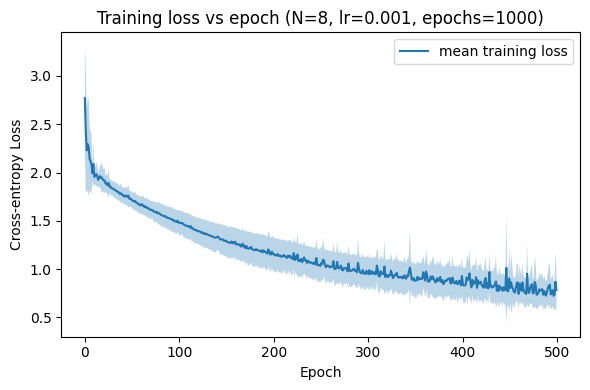

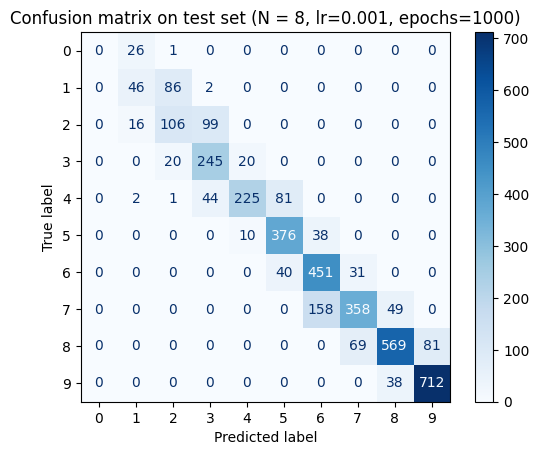

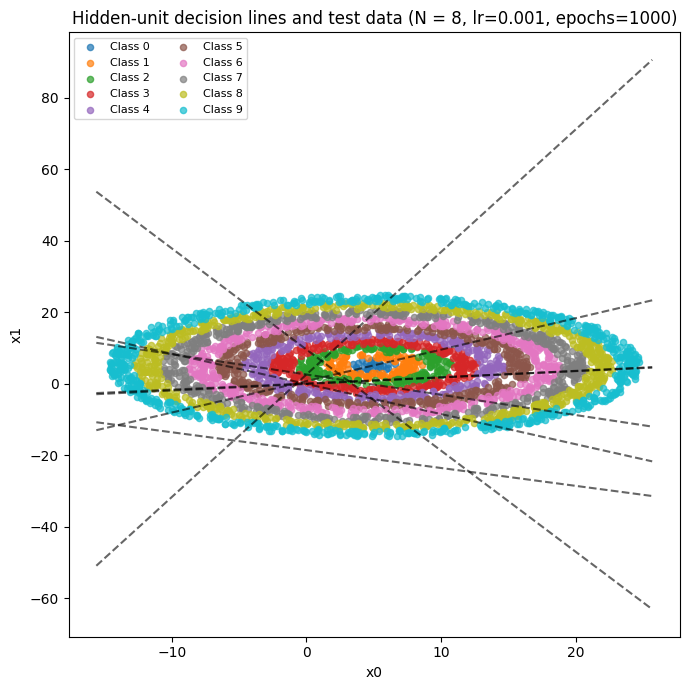

In [57]:
# -------------------------
# Plot Loss curve
# -------------------------

all_losses = np.array(all_losses)
mean_loss = all_losses.mean(axis=0)
std_loss = all_losses.std(axis=0)

plt.figure(figsize=(6,4))
plt.plot(mean_loss, label='mean training loss')
plt.fill_between(np.arange(len(mean_loss)),
                 mean_loss - std_loss,
                 mean_loss + std_loss,
                 alpha=0.3)
#plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy Loss')
plt.title(f'Training loss vs epoch (N=8, lr={lr}, epochs={epochs})')
plt.legend()
plt.tight_layout()

# save figure
plt.savefig(f"training_loss_N8_nn_lr{lr}_epochs{epochs}.png", dpi=300)

plt.show()

# -------------------------
# Confusion Matrix on the best model
# -------------------------
best_idx = int(np.argmax(all_test_acc))
best_pred = preds[best_idx]

cm = confusion_matrix(L_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion matrix on test set (N = 8, lr={lr}, epochs={epochs})')

# save figure
plt.savefig(f"confusion_matrix_N8_nn_lr{lr}_epochs{epochs}.png", dpi=300)

plt.show()

# -------------------------
# Plot the hidden unit decision lines
# -------------------------

best_model = models[best_idx]

plt.figure(figsize=(7,7))

# plot test points
for c in range(numCat):
    mask = (L_test == c)
    plt.scatter(X_test[mask, 0], X_test[mask, 1], s=20, label=f"Class {c}", alpha=0.7)

# plot hidden unit decision lines
x0_vals = np.linspace(X_test[:,0].min()-1, X_test[:,0].max()+1, 200)

for i in range(best_model.W1.shape[0]):
    w0 = best_model.W1[i, 0]
    w1 = best_model.W1[i, 1]
    b = best_model.b1[0, i]

    if abs(w1) > 1e-12:
        x1_vals = -(w0 * x0_vals + b) / w1
        plt.plot(x0_vals, x1_vals, 'k--', alpha=0.6)
    else:
        x_vertical = -b / w0
        plt.axvline(x_vertical, linestyle='--', color='k', alpha=0.6)

plt.xlabel('x0')
plt.ylabel('x1')
plt.title(f'Hidden-unit decision lines and test data (N = 8, lr={lr}, epochs={epochs})')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

plt.savefig(f"hidden_unit_decision_lines_N8_nn_lr{lr}_epochs{epochs}.png", dpi=300)

plt.show()

Varying the learning rate and number of epochs did not noticeably change the test accuracy, indicating that the model converges to a local minimum regarless of the training schedule. The limiting factor is the structure of the model, especially the number of hidden neurons and layers.

Each hidden neuron represents a single linear decision boundary (from the ReLU activation). The output layer simply performs a weighted sum of these linear partitions. With few neurons, the network lacks the "resolution" to approximate complex, non-linear class boundaries, leading to underfitting.

What kind of network would solve it better? 
- Wider shallow network (N=20, 50, 100): Increases the number of lines, allowing for more regions in the plane.
- Deeper neural network: Allows for hierarchical nonlinear transformations, instead of only one round of linear partitioning. 
- Convolutional Neural Networks (CNN): Utilizes spatial hierarchies to detect local patterns (edges, textures) 
- SVM with kernels: Maps the 2D input space to higher dimensional sapce (say z = elliptical distance of X1, X2 from center), where a simple linear plane (a < z < b) can seperate the classes

In [58]:
# -------------------------
# Compare different hidden layer sizes (N)
# -------------------------

hidden_list = [15, 10, 7, 5]
results = {}

for N in hidden_list:
    test_accs = []
    for run in range(10):
        seed = int(time.time() * 1e6) % (2**32 - 1) + run + N
        model, losses, train_acc, test_acc, test_pred = train_model(
            X_train, L_train, X_test, L_test, numCat,
            hidden_dim=N, lr=0.01, epochs=500, batch_size=64, seed=seed
        )
        test_accs.append(test_acc)
    results[N] = test_accs

for N in hidden_list:
    vals = np.array(results[N])
    print(f"N={N}: mean={vals.mean():.4f}, std={vals.std():.4f}, max={vals.max():.4f}")

N=15: mean=0.7781, std=0.0697, max=0.8410
N=10: mean=0.7400, std=0.0850, max=0.8690
N=7: mean=0.6753, std=0.0606, max=0.7450
N=5: mean=0.4797, std=0.1465, max=0.7025


Based on the results, incerasing N (the number of hidden neurons) does not improve the accuracy significantly. Since each neuron in the hidden layer, acts like an addditional decision boundary in the plane, it cannot capture for a nonlinear class boundary such as the dataset. Adding more hidden layers would allow for more complex decision boundaries.